In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

true_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/True.csv')
fake_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Fake.csv')

true_df['label'] = 1
fake_df['label'] = 0

df = pd.concat([true_df, fake_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


---
Analisi esplorativa dei dati

In [4]:
# distribuzione label
df['label'].value_counts()

,count
label,
0,23481
1,21417


In [6]:
# lunghezza corpo del testo
df['text_length'] = df['text'].apply(lambda x: len(x.split()))
df.groupby('label')['text_length'].mean()

,text_length
label,
0,423.197905
1,385.640099


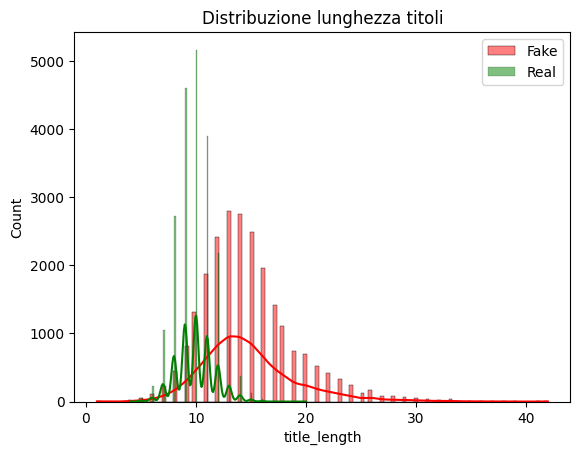

In [7]:
# lunghezza titoli
df['title_length'] = df['title'].apply(lambda x: len(x.split()))

sns.histplot(df[df["label"] == 0]["title_length"], color="red", label="Fake", kde=True)
sns.histplot(df[df["label"] == 1]["title_length"], color="green", label="Real", kde=True)
plt.legend()
plt.title("Distribuzione lunghezza titoli")
plt.show()

I titoli delle fake news sono mediamente più brevi

In [8]:
# analisi categorie
df["subject"].value_counts().head(10)

,count
subject,
politicsNews,11272
worldnews,10145
News,9050
politics,6841
left-news,4459
Government News,1570
US_News,783
Middle-east,778


In [9]:
# distribuzione categorie
category_distribution = pd.crosstab(df["subject"], df["label"])
category_distribution


label,0,1
subject,,
Government News,1570,0
Middle-east,778,0
News,9050,0
US_News,783,0
left-news,4459,0
politics,6841,0
politicsNews,0,11272
worldnews,0,10145


---
Preprocessing testo

In [10]:
import string
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def data_cleaner(text):
  text = text.lower()
  text = re.sub(r'\d+', '', text)
  text = text.translate(str.maketrans('', '', string.punctuation))
  words = text.split()
  words = [word for word in words if word not in ENGLISH_STOP_WORDS]
  return ' '.join(words)

df["clean_text"] = df["text"].apply(data_cleaner)

---
Estrazione topic

In [11]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(
    max_df=0.95,
    min_df=10,
    stop_words='english'
)

X_topics = vectorizer.fit_transform(df["clean_text"])

In [12]:
lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda.fit(X_topics)

LatentDirichletAllocation(n_components=5, random_state=42)

In [13]:
#argomenti più soggetti alle fake news
def display_topics(model, feature_names, n_top_words=10):
  for idx, topic in enumerate(model.components_):
    print(f"Topic {idx}:")
    print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))
    print()

display_topics(lda, vectorizer.get_feature_names_out())

Topic 0:
said trump house president republican senate reuters new tax state

Topic 1:
trump president donald clinton people just said hillary like campaign

Topic 2:
people said police black just law like city state school

Topic 3:
said government reuters state minister people military united syria country

Topic 4:
said trump russia north president china russian united clinton korea



In [14]:
# parole più frequenti fake vs vere
from collections import Counter

fake_text = df[df["label"] == 0]["clean_text"]
true_text = df[df["label"] == 1]["clean_text"]

def most_common_words(text, n=20):
  words = ' '.join(text).split()
  word_counts = Counter(words)
  return word_counts.most_common(n)

fake_common_words = most_common_words(fake_text, 20)
true_common_words = most_common_words(true_text, 20)

print("Parole più frequenti in fake news:")
print(fake_common_words)
print("\nParole più frequenti in notizie vere:")
print(true_common_words)

Parole più frequenti in fake news:
[('s', 130422), ('trump', 73933), ('t', 40616), ('said', 31013), ('people', 25963), ('president', 25586), ('just', 20176), ('clinton', 18011), ('obama', 17813), ('like', 17621), ('donald', 17215), ('new', 14158), ('news', 14126), ('hillary', 13565), ('white', 12778), ('time', 12728), ('state', 12525), ('media', 10982), ('campaign', 10571), ('house', 10556)]

Parole più frequenti in notizie vere:
[('said', 99017), ('s', 46053), ('trump', 42062), ('reuters', 28306), ('president', 25223), ('state', 18556), ('government', 17851), ('new', 16712), ('house', 16295), ('states', 16064), ('united', 15566), ('republican', 15273), ('people', 14605), ('told', 14243), ('washington', 12088), ('trump’s', 11621), ('election', 11349), ('party', 11254), ('year', 10891), ('donald', 10294)]


Le categorie di argomenti politici/sociali risultano più soggetti alla disinformazione.

---
Tf-idf Vectorizer

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_text"])
y = df["label"]

---
Split Train e Test

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

---
Addestramento modelli

Regressione Logistica:


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

#modello base

lr_base = LogisticRegression(max_iter=1000)
lr_base.fit(X_train, y_train)

#modello con regolazione più forte
lr_reg = LogisticRegression(C=0.1, max_iter=1000)
lr_reg.fit(X_train, y_train)

print("Modello base:")
print(classification_report(y_test, lr_base.predict(X_test)))

print("\nModello con regolazione più forte:")
print(classification_report(y_test, lr_reg.predict(X_test)))

Modello base:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4669
           1       0.98      0.99      0.99      4311

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


Modello con regolazione più forte:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      4669
           1       0.97      0.98      0.98      4311

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



MLP:

In [18]:
from sklearn.neural_network import MLPClassifier

mlp_small = MLPClassifier(hidden_layer_sizes=(50,), max_iter=300, solver='adam', random_state=42)
mlp_big = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, solver='adam', random_state=42)

mlp_small.fit(X_train, y_train)
mlp_big.fit(X_train, y_train)

print("MLP 50 neuroni:")
print(classification_report(y_test, mlp_small.predict(X_test)))

print("\nMLP 100 neuroni:")
print(classification_report(y_test, mlp_big.predict(X_test)))

MLP 50 neuroni:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4669
           1       0.99      0.99      0.99      4311

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


MLP 100 neuroni:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4669
           1       0.99      0.99      0.99      4311

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



---
Valutazione e confronto modelli migliori

In [19]:
from sklearn.metrics import accuracy_score

#Logistic Regression
y_pred_lr = lr_base.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

#MLP
y_pred_mlp = mlp_big.predict(X_test)

print("MLP Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("\nClassification Report:\n", classification_report(y_test, y_pred_mlp))

Logistic Regression
Accuracy: 0.988641425389755

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4669
           1       0.98      0.99      0.99      4311

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

MLP Classifier
Accuracy: 0.9918708240534521

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4669
           1       0.99      0.99      0.99      4311

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



---
Esportazione modello con pickle

In [21]:
import pickle

with open('/content/drive/MyDrive/Colab Notebooks/fake_news_model.pkl', 'wb') as file:
    pickle.dump(mlp_big, file)

In [22]:
with open('/content/drive/MyDrive/Colab Notebooks/tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)

L'**analisi** sulle **categorie** di notizie ha mostrato come le fake news non siano distribuite uniformemente, ma che risultino più frequenti in specifici ambiti, in particolare quelli legati a tematiche politiche.

Dal punto di vista testuale invece, possiamo notare che le fake news presentano mediamente una lunghezza leggermente diversa, sia nel corpo del testo sia nei titoli.

---

L'**analisi** dei **topic** ci ha permesso di individuare argomenti ricorrenti all'interno delle fake news, andando a segnalare gli argomenti principali in cui si concentra la disinformaizone. l'analisi lessicale invece ha sottolineato la ripetizione di parole chiave tipiche delle fake news

---

Nella **fase** di **classificazione** sono stati confrontati i due modelli Logistic Regression e MLP, con i quali abbiamo potuto osservare che entrambi i modelli restituiscono prestazioni elevate simili, ma che nel modello MLP abbiamo un costo computazionale maggiore.
